# F3NinaD — Rigor estatístico: La Niña

**Projeto:** NINO-BRASIL — Oceanografia Física — UFPE  
**Código canônico:** `F3NinaD`  
**Objeto de estudo:** ciclo de vida da La Niña no Pacífico tropical  
**Família de hipótese:** `HIP0`

## 1. Contexto e delimitação científica

Este notebook pergunta quais variáveis realmente mudam entre as quatro fases dentro dos mesmos eventos. Ele funciona como filtro inferencial do comportamento multivariado, não como repetição do ranking de correlações do notebook anterior.

## 2. Pergunta científica

Quais diferenças entre períodos sobrevivem ao controle de multiplicidade?

## 3. Hipótese específica

Para La Niña, ao menos parte das 31 variáveis apresenta distribuições diferentes entre as quatro fases com tamanho de efeito consistente; outras variáveis permanecerão indistinguíveis e deverão ser registradas como resultado nulo.

A hipótese poderá ser sustentada, parcialmente sustentada ou rejeitada; a execução do notebook não antecipa o resultado.

## 4. Motivação para o teste e unidade de análise

Friedman é usado porque as quatro fases são medidas repetidas dentro do evento e não se presume normalidade. Kendall W quantifica o tamanho do efeito e BH-FDR controla a família de 31 testes; semanas não entram como réplicas independentes.

## 5. Metodologia

Friedman pareado por evento, Kendall W e BH-FDR separado para o sinal analisado.

## 6. Resultados esperados e contrato de saída

Resultados esperados significam produtos necessários para responder à pergunta, não valores ou significâncias presumidos:

- estatística de Friedman, p, q BH-FDR e Kendall W para cada variável.
- ranking apenas dos discriminantes confirmados no sinal isolado.
- registro explícito das variáveis sem evidência de diferença entre fases.

- figuras públicas iniciadas por `FigF3NinaD`;
- tabelas públicas iniciadas por `TabF3NinaD`;
- primeiro par reservado: `FigF3NinaD1` ↔ `TabF3NinaD1`;
- toda interpretação deve apontar para tabela, run_id, unidade, amostra e limitações.

## 7. Fundamentação científica mínima

1. Benjamini, Y.; Hochberg, Y. (1995). Controlling the False Discovery Rate. Journal of the Royal Statistical Society B, 57, 289–300.
2. Bretherton, C. S. et al. (1999). The Effective Number of Spatial Degrees of Freedom. Journal of Climate, 12, 1990–2009.
3. Wilks, D. S. (2016). The Stippling Shows Statistically Significant Grid Points. Bulletin of the American Meteorological Society, 97, 2263–2273.

## Premissas de validade e limites de interpretação

- Toda conclusão deve nascer de uma tabela `Tab...` persistida antes da figura correspondente.
- A execução é determinística e usa somente entradas declaradas no inventário mostrado abaixo.
- Notebook executado não implica hipótese confirmada; gates científicos são exibidos como resultados.
- El Niño e La Niña são analisados isoladamente; nenhum composto mistura os dois sinais.
- Evento é a unidade independente; semanas descrevem a trajetória interna do evento.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
NOTEBOOK_CODE = 'F3NinaD'
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'official')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
if RUN_PIPELINE:
    raise RuntimeError('O núcleo numérico deve ser executado pelo runner da fase, antes do notebook.')
from nino_brasil.notebook_workflows import NotebookWorkflow
workflow = NotebookWorkflow(ROOT, NOTEBOOK_CODE, mode=MODE)
workflow.describe()

{
  "notebook_code": "F3NinaD",
  "phase": 3,
  "enso_type": "la_nina",
  "mode": "official",
  "execution_policy": "numeric-core-first-viewer-publisher"
}


{'notebook_code': 'F3NinaD',
 'phase': 3,
 'enso_type': 'la_nina',
 'mode': 'official',
 'execution_policy': 'numeric-core-first-viewer-publisher'}

## Dados

In [2]:
input_inventory = workflow.input_inventory()
display(input_inventory)
workflow.require_inputs()

,role,path,required,exists,bytes
0,Friedman/FDR,data\processed\parquet\statistics\F3Nina\TabF3...,True,True,9407


## Resultados

,notebook_code,ordinal,namespace,figure_code,table_code,figure_path,table_path,manifest_path,figure_sha256,table_sha256,run_id
0,F3NinaD,1,fase3_nina,FigF3NinaD1,TabF3NinaD1,C:\DEV\NINO26\data\processed\figures\fase3_nin...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,04488f2cfb0100a8f5e0dbd379f72e7e984857211aac12...,d181a5fea46d640ec818e8d600a97631dd43f7c3442260...,20260714T202702Z_5538a635


,tipo,variavel,friedman_chi2,p_friedman,kendall_w_entre_fases,n_eventos_completos,unidade_inferencial,interpretacao,q_friedman_bh,significativo_friedman_fdr,friedman_family_id,friedman_family_size,friedman_valid_p_count,friedman_fdr_alpha,resultado_confirmatorio
0,la_nina,nino34_ssta,29.727273,0.000002,0.900826,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000049,True,F3_friedman_la_nina_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
3,la_nina,tilt_slope,27.109091,0.000006,0.821488,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000087,True,F3_friedman_la_nina_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
2,la_nina,tilt_m,23.618182,0.000030,0.715702,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000310,True,F3_friedman_la_nina_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
21,la_nina,tcwv_anom,21.436364,0.000085,0.649587,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.000662,True,F3_friedman_la_nina_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
9,la_nina,wwv,19.254545,0.000242,0.583471,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.001251,True,F3_friedman_la_nina_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
26,la_nina,u850_anom,19.254545,0.000242,0.583471,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.001251,True,F3_friedman_la_nina_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
10,la_nina,t50m,18.600000,0.000331,0.563636,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.001282,True,F3_friedman_la_nina_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
4,la_nina,ohc_0_100,18.600000,0.000331,0.563636,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.001282,True,F3_friedman_la_nina_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
23,la_nina,sshf_anom,18.163636,0.000407,0.550413,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.001402,True,F3_friedman_la_nina_all_variables,31,31,0.05,confirmado_q_bh_le_alpha
18,la_nina,u10_anom,17.618182,0.000527,0.533884,11,evento_pareado_nas_quatro_fases,Kendall W e p de Friedman brutos; confirmacao ...,0.001634,True,F3_friedman_la_nina_all_variables,31,31,0.05,confirmado_q_bh_le_alpha


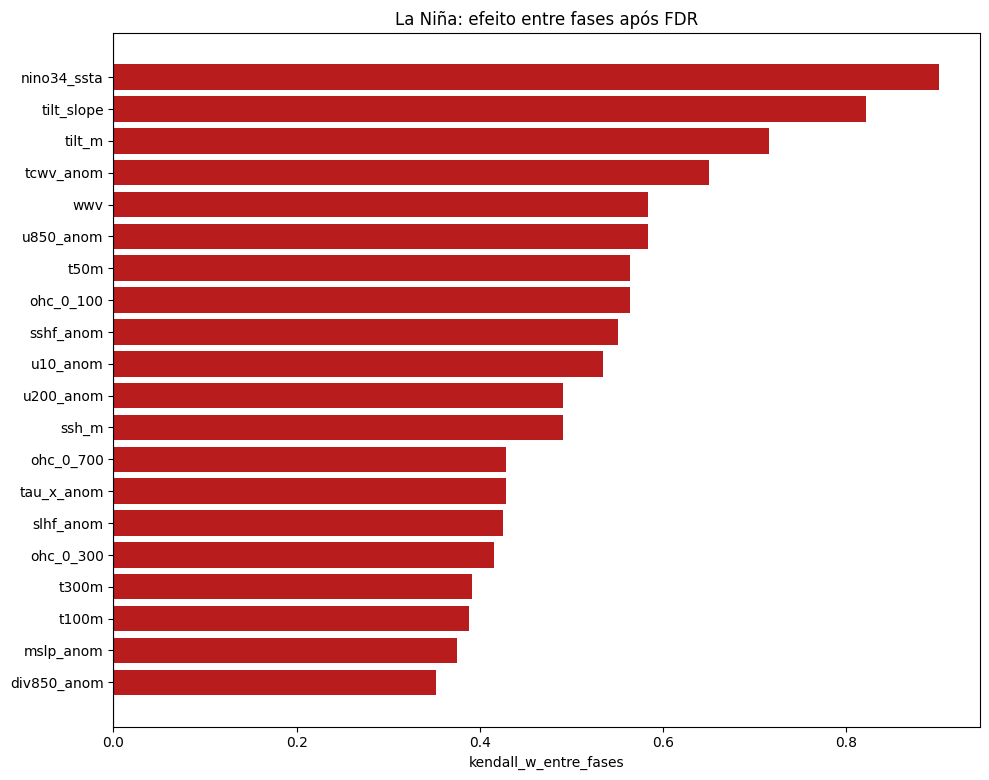

In [3]:
result = workflow.run()
display(result.artifacts)
display(result.summary)

## Figuras para verificação rápida

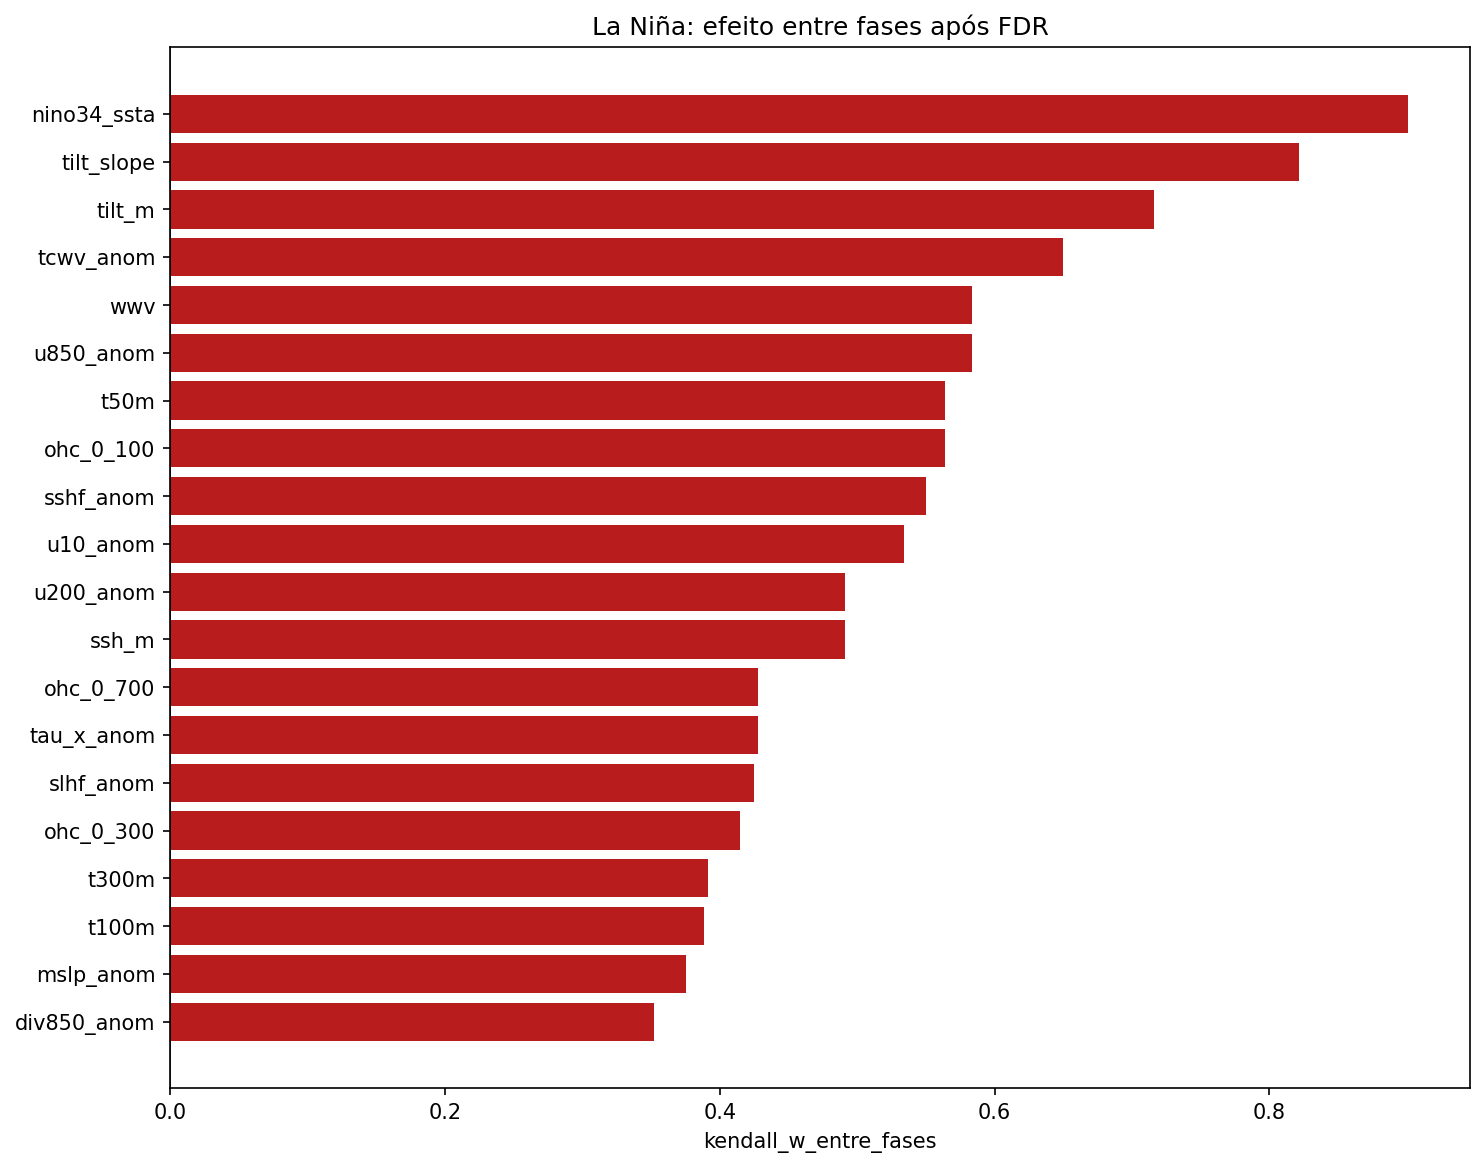

In [4]:
from IPython.display import Image, display

for artifact in result.artifacts.itertuples(index=False):
    display(Image(filename=str(artifact.figure_path)))

## Conclusões

In [5]:
for item in result.takeaways:
    print(f'- {item}')
print('\nLimitações:')
for item in result.limitations:
    print(f'- {item}')

- A tabela auditada contém 25 linhas para La Niña.
- A leitura mantém eventos independentes separados e não soma semanas como novas réplicas.

Limitações:
- A figura resume a tabela publicada; consulte a tabela completa e seu manifesto antes de interpretar valores individuais.
- Resultados negativos ou tabelas vazias são preservados e não são convertidos em falha técnica.
